# Task 12G real–synthetic projection angle calibration evidence

> **Authority: `informational_read_only`.** This Notebook reads frozen
> synthetic projections, raw clinical DICOM and existing QA records. It does
> not write dataset artifacts, alter preprocessing, change any gate, or approve
> 500-case generation.

**Question:** Is the current clinical stack corrected by **+15 views**
(the frozen SIMIND/DICOM-to-projector basis mapping), or should it instead use
the brightness-correlation optimum near **+18 views**?

Evidence is evaluated in this order:

1. DICOM `ImageOrientationPatient` and `StartAngle` geometry — authoritative.
2. The frozen PAR-S projector/source-axis contract — authoritative.
3. Cross-patient angular count correlation — diagnostic only.


## 1. Setup and immutable inputs

The input inventory is snapshotted before analysis. The final cell verifies
that every tracked input retains the same size and modification timestamp.


In [1]:
from collections import Counter
from pathlib import Path
import json
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pydicom
from IPython.display import Markdown, display

DATASET_ROOT = Path(r"D:\PFE-U\PAR\outputs\pars_v2_linux50_v2")
QA_ROOT = Path(r"D:\PFE-U\PAR\outputs\pars_v2_linux50_v2_qa")
CLINICAL_ROOT = Path(r"D:\PFE-U\PAR-D\data\raw\CLIN")
EXPECTED_MANIFEST_SHA256 = (
    "d44a77f4604bc1df192c6af0674341c704d4e069d1665e1fe159832adfeae722"
)
PROJECTION_SHAPE = (60, 128, 128)


def read_json(path):
    value = json.loads(Path(path).read_text(encoding="utf-8"))
    if not isinstance(value, dict):
        raise TypeError(f"{path} must contain a JSON object")
    return value


marker = read_json(DATASET_ROOT / "DATASET_COMPLETE.json")
generator_gate = read_json(QA_ROOT / "generator_gate.json")
assert marker["manifest_sha256"] == EXPECTED_MANIFEST_SHA256
assert generator_gate["manifest_sha256"] == EXPECTED_MANIFEST_SHA256
assert marker["case_count"] == 50

case_rows = [
    json.loads(line)
    for line in Path(generator_gate["case_metrics_path"])
    .read_text(encoding="utf-8")
    .splitlines()
    if line.strip()
]
whole_liver_ids = [
    row["case_id"]
    for row in case_rows
    if row["injection_territory"] == "whole_liver"
]
projection_paths = sorted(
    path
    for path in CLINICAL_ROOT.rglob("*projection.dcm")
    if "_rgb_sc_original_backup" not in str(path)
)
assert len(whole_liver_ids) == 32
assert len(projection_paths) == 16


def synthetic_a00_path(case_id):
    record = read_json(
        DATASET_ROOT / "cases" / case_id / "case_record.json"
    )
    return DATASET_ROOT / record["artifacts"]["projection_a00"]["relative_path"]


tracked_input_paths = [
    DATASET_ROOT / "DATASET_COMPLETE.json",
    DATASET_ROOT / marker["manifest_relative_path"],
    QA_ROOT / "generator_gate.json",
    Path(generator_gate["case_metrics_path"]),
    *projection_paths,
    *(synthetic_a00_path(case_id) for case_id in whole_liver_ids),
]
input_snapshot_before = {
    str(path.resolve()): (path.stat().st_size, path.stat().st_mtime_ns)
    for path in tracked_input_paths
}

display(
    pd.DataFrame(
        [
            {
                "dataset_id": marker["dataset_id"],
                "synthetic_whole_liver_cases": len(whole_liver_ids),
                "clinical_projection_cases": len(projection_paths),
                "manifest_sha256": marker["manifest_sha256"],
                "authority": "informational_read_only",
            }
        ]
    )
)


,dataset_id,synthetic_whole_liver_cases,clinical_projection_cases,manifest_sha256,authority
0,PAR-S-TARE-HCC-NoPVI-SYN-v2-linux50,32,16,d44a77f4604bc1df192c6af0674341c704d4e069d1665e...,informational_read_only


## 2. Geometry: DICOM angle basis versus PAR-S projector basis

Patient coordinates use DICOM LPS: +X is left and +Y is posterior.
`ImageOrientationPatient` gives the detector-plane axes. Their cross product
points inward, so its negative gives the outward camera direction.

For these GE NM files, the measured detector direction satisfies
`patient azimuth = 90° − DICOM angle`. In the PAR-S source frame,
`patient azimuth = 180° + projector angle`. Therefore:

**projector angle = (270° − DICOM angle) mod 360°**

This is the same 90° basis offset already frozen between SIMIND 180° and
projector 90°; the sign is determined by the DICOM CW acquisition order.


In [2]:
def circular_distance_deg(first, second):
    return abs((float(first) - float(second) + 180.0) % 360.0 - 180.0)


def azimuth_xy_deg(vector):
    vector = np.asarray(vector, dtype=np.float64)
    return float(np.degrees(np.arctan2(vector[1], vector[0])) % 360.0)


def clinical_geometry_row(path):
    dataset = pydicom.dcmread(str(path), stop_before_pixels=True)
    rotation = dataset.RotationInformationSequence[0]
    detector = dataset.DetectorInformationSequence[0]
    start = float(rotation.StartAngle)
    step = abs(float(getattr(rotation, "AngularStep", 6.0)))
    direction = str(rotation.RotationDirection).upper()
    assert direction == "CW", f"Unexpected rotation direction in {path}"

    image_x = np.asarray(detector.ImageOrientationPatient[:3], dtype=np.float64)
    image_y = np.asarray(detector.ImageOrientationPatient[3:], dtype=np.float64)
    detector_inward = np.cross(image_x, image_y)
    detector_outward = -detector_inward / np.linalg.norm(detector_inward)
    measured_outward_azimuth = azimuth_xy_deg(detector_outward)
    expected_outward_azimuth = (90.0 - start) % 360.0

    current_raw_index_at_view0 = (
        int(round((start - 90.0) / step)) % PROJECTION_SHAPE[0]
    )
    candidate_15_raw_index = (
        current_raw_index_at_view0 - 15
    ) % PROJECTION_SHAPE[0]
    candidate_18_raw_index = (
        current_raw_index_at_view0 - 18
    ) % PROJECTION_SHAPE[0]
    projector_angle_at_raw0 = (270.0 - start) % 360.0

    def projector_angle(raw_index):
        return (projector_angle_at_raw0 + raw_index * step) % 360.0

    candidate_15_angle = projector_angle(candidate_15_raw_index)
    candidate_18_angle = projector_angle(candidate_18_raw_index)
    return {
        "patient": path.parent.name,
        "start_angle_deg": start,
        "direction": direction,
        "IOP_outward_azimuth_deg": measured_outward_azimuth,
        "90_minus_start_deg": expected_outward_azimuth,
        "IOP_basis_error_deg": circular_distance_deg(
            measured_outward_azimuth, expected_outward_azimuth
        ),
        "current_raw_frame_at_view0": current_raw_index_at_view0,
        "+15_raw_frame_at_view0": candidate_15_raw_index,
        "+18_raw_frame_at_view0": candidate_18_raw_index,
        "+15_projector_angle_deg": candidate_15_angle,
        "+18_projector_angle_deg": candidate_18_angle,
        "+15_error_to_view0_90deg": circular_distance_deg(
            candidate_15_angle, 90.0
        ),
        "+18_error_to_view0_90deg": circular_distance_deg(
            candidate_18_angle, 90.0
        ),
    }


geometry_frame = pd.DataFrame(
    [clinical_geometry_row(path) for path in projection_paths]
).sort_values("patient", ignore_index=True)
geometry_summary = pd.DataFrame(
    [
        {
            "clinical_cases": len(geometry_frame),
            "max_IOP_basis_error_deg": geometry_frame[
                "IOP_basis_error_deg"
            ].max(),
            "max_+15_error_to_90deg": geometry_frame[
                "+15_error_to_view0_90deg"
            ].max(),
            "min_+18_error_to_90deg": geometry_frame[
                "+18_error_to_view0_90deg"
            ].min(),
            "geometry_supported_candidate": "+15 views",
        }
    ]
)
assert geometry_frame["IOP_basis_error_deg"].max() < 1e-3
assert geometry_frame["+15_error_to_view0_90deg"].max() < 0.2
assert geometry_frame["+18_error_to_view0_90deg"].min() > 18.0
display(geometry_summary)
display(
    geometry_frame[
        [
            "patient",
            "start_angle_deg",
            "IOP_outward_azimuth_deg",
            "current_raw_frame_at_view0",
            "+15_raw_frame_at_view0",
            "+18_raw_frame_at_view0",
            "+15_projector_angle_deg",
            "+18_projector_angle_deg",
            "+15_error_to_view0_90deg",
            "+18_error_to_view0_90deg",
        ]
    ].round(3)
)


,clinical_cases,max_IOP_basis_error_deg,max_+15_error_to_90deg,min_+18_error_to_90deg,geometry_supported_candidate
0,16,0.000025,0.19,18.1,+15 views


,patient,start_angle_deg,IOP_outward_azimuth_deg,current_raw_frame_at_view0,+15_raw_frame_at_view0,+18_raw_frame_at_view0,+15_projector_angle_deg,+18_projector_angle_deg,+15_error_to_view0_90deg,+18_error_to_view0_90deg
0,patient_AC,180.10,269.90,15,0,57,89.90,71.90,0.10,18.10
1,patient_AJ,180.10,269.90,15,0,57,89.90,71.90,0.10,18.10
2,patient_BF,174.10,275.90,14,59,56,89.90,71.90,0.10,18.10
3,patient_BG,0.19,89.81,45,30,27,89.81,71.81,0.19,18.19
4,patient_BJe,180.10,269.90,15,0,57,89.90,71.90,0.10,18.10
5,patient_Bab,0.10,89.90,45,30,27,89.90,71.90,0.10,18.10
6,patient_Cjo,180.10,269.90,15,0,57,89.90,71.90,0.10,18.10
7,patient_DCM,180.10,269.90,15,0,57,89.90,71.90,0.10,18.10
8,patient_DEC,180.10,269.90,15,0,57,89.90,71.90,0.10,18.10
9,patient_DR,180.10,269.90,15,0,57,89.90,71.90,0.10,18.10


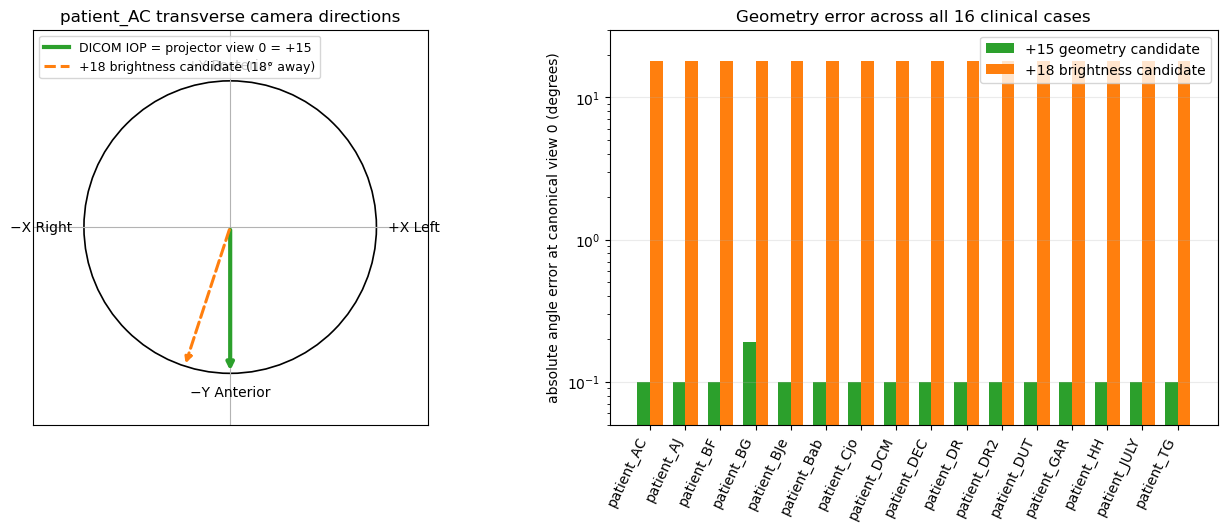

In [3]:
patient_ac_geometry = geometry_frame.set_index("patient").loc["patient_AC"]
figure, axes = plt.subplots(1, 2, figsize=(13, 5.2), constrained_layout=True)
direction_axis = axes[0]
circle = plt.Circle((0.0, 0.0), 1.0, fill=False, linewidth=1.2)
direction_axis.add_patch(circle)
direction_axis.axhline(0.0, linewidth=0.8, color="0.7")
direction_axis.axvline(0.0, linewidth=0.8, color="0.7")
direction_axis.text(1.08, 0.0, "+X Left", va="center")
direction_axis.text(-1.08, 0.0, "−X Right", ha="right", va="center")
direction_axis.text(0.0, 1.08, "+Y Posterior", ha="center")
direction_axis.text(0.0, -1.08, "−Y Anterior", ha="center", va="top")

geometry_angle = np.deg2rad(270.0)
brightness_angle = np.deg2rad(
    (180.0 + patient_ac_geometry["+18_projector_angle_deg"]) % 360.0
)
direction_axis.annotate(
    "",
    xy=(np.cos(geometry_angle), np.sin(geometry_angle)),
    xytext=(0.0, 0.0),
    arrowprops={
        "arrowstyle": "-|>",
        "linewidth": 3.0,
        "color": "tab:green",
    },
)
direction_axis.annotate(
    "",
    xy=(np.cos(brightness_angle), np.sin(brightness_angle)),
    xytext=(0.0, 0.0),
    arrowprops={
        "arrowstyle": "-|>",
        "linewidth": 2.2,
        "linestyle": "--",
        "color": "tab:orange",
    },
)
direction_axis.plot(
    [], [], color="tab:green", linewidth=3.0,
    label="DICOM IOP = projector view 0 = +15",
)
direction_axis.plot(
    [], [], color="tab:orange", linewidth=2.2, linestyle="--",
    label="+18 brightness candidate (18° away)",
)
direction_axis.set_xlim(-1.35, 1.35)
direction_axis.set_ylim(-1.35, 1.35)
direction_axis.set_aspect("equal")
direction_axis.set_xticks([])
direction_axis.set_yticks([])
direction_axis.set_title("patient_AC transverse camera directions")
direction_axis.legend(loc="upper left", fontsize=9)

bar_axis = axes[1]
indices = np.arange(len(geometry_frame))
bar_axis.bar(
    indices - 0.18,
    geometry_frame["+15_error_to_view0_90deg"],
    width=0.36,
    color="tab:green",
    label="+15 geometry candidate",
)
bar_axis.bar(
    indices + 0.18,
    geometry_frame["+18_error_to_view0_90deg"],
    width=0.36,
    color="tab:orange",
    label="+18 brightness candidate",
)
bar_axis.set_xticks(indices, geometry_frame["patient"], rotation=65, ha="right")
bar_axis.set_ylabel("absolute angle error at canonical view 0 (degrees)")
bar_axis.set_title("Geometry error across all 16 clinical cases")
bar_axis.set_yscale("log")
bar_axis.set_ylim(0.05, 30.0)
bar_axis.legend()
bar_axis.grid(axis="y", alpha=0.25)
plt.show()


## 3. Cross-cohort brightness correlation — diagnostic evidence

The next section compares 32 synthetic `whole_liver` cases with 16 clinical
cases. Each case's 60-view total-count curve is divided by its own mean.
This intentionally removes absolute scale, but it cannot remove differences in
patient anatomy, liver position, activity distribution, attenuation or protocol.

Therefore the correlation peak may describe the two cohorts' average brightness
pattern; it cannot override the DICOM camera geometry.


In [4]:
def correlation(first, second):
    first = np.asarray(first, dtype=np.float64).ravel()
    second = np.asarray(second, dtype=np.float64).ravel()
    first = first - first.mean()
    second = second - second.mean()
    denominator = np.linalg.norm(first) * np.linalg.norm(second)
    return float(np.dot(first, second) / denominator)


def load_synthetic_projection(case_id):
    path = synthetic_a00_path(case_id)
    raw = np.memmap(
        path,
        dtype="<f4",
        mode="r",
        shape=PROJECTION_SHAPE,
    )
    return np.asarray(raw[:, ::-1, :], dtype=np.float32)


def canonicalize_current_clinical(path):
    dataset = pydicom.dcmread(str(path))
    raw = dataset.pixel_array.astype(np.float32)
    raw = raw * float(getattr(dataset, "RescaleSlope", 1.0))
    raw += float(getattr(dataset, "RescaleIntercept", 0.0))
    rotation = dataset.RotationInformationSequence[0]
    start = float(rotation.StartAngle)
    step = abs(float(getattr(rotation, "AngularStep", 6.0)))
    direction = str(rotation.RotationDirection).upper()
    source_indices = np.arange(raw.shape[0])
    if direction == "CCW":
        raw = raw[::-1].copy()
        source_indices = source_indices[::-1].copy()
        effective_start = (start + (raw.shape[0] - 1) * step) % 360.0
    else:
        effective_start = start
    shift = int(round((effective_start - 90.0) / step)) % raw.shape[0]
    current = np.roll(raw, -shift, axis=0)
    current_source_indices = np.roll(source_indices, -shift)
    return raw, current, current_source_indices, {
        "start": start,
        "step": step,
        "direction": direction,
        "current_shift": shift,
    }


def normalized_view_curve(stack):
    curve = np.asarray(stack, dtype=np.float64).sum(axis=(1, 2))
    return curve / curve.mean()


synthetic_stacks = {
    case_id: load_synthetic_projection(case_id)
    for case_id in whole_liver_ids
}
clinical_stacks = {}
clinical_source_indices = {}
clinical_metadata = {}
for path in projection_paths:
    patient = path.parent.name
    _, current, source_indices, metadata = canonicalize_current_clinical(path)
    clinical_stacks[patient] = current
    clinical_source_indices[patient] = source_indices
    clinical_metadata[patient] = metadata

synthetic_curves = np.stack(
    [normalized_view_curve(stack) for stack in synthetic_stacks.values()]
)
clinical_curves = np.stack(
    [normalized_view_curve(stack) for stack in clinical_stacks.values()]
)
synthetic_mean_curve = synthetic_curves.mean(axis=0)
clinical_mean_curve = clinical_curves.mean(axis=0)
correlation_by_shift = np.array(
    [
        correlation(
            synthetic_mean_curve,
            np.roll(clinical_mean_curve, shift),
        )
        for shift in range(60)
    ]
)

rng = np.random.default_rng(20260717)
bootstrap_best_shifts = []
bootstrap_delta_18_minus_15 = []
for _ in range(2000):
    synthetic_sample = synthetic_curves[
        rng.integers(0, len(synthetic_curves), len(synthetic_curves))
    ].mean(axis=0)
    clinical_sample = clinical_curves[
        rng.integers(0, len(clinical_curves), len(clinical_curves))
    ].mean(axis=0)
    values = np.array(
        [
            correlation(synthetic_sample, np.roll(clinical_sample, shift))
            for shift in range(60)
        ]
    )
    bootstrap_best_shifts.append(int(np.argmax(values)))
    bootstrap_delta_18_minus_15.append(float(values[18] - values[15]))

bootstrap_counts = Counter(bootstrap_best_shifts)
delta_interval = np.quantile(
    bootstrap_delta_18_minus_15,
    [0.025, 0.50, 0.975],
)
statistical_summary = pd.DataFrame(
    [
        {
            "zero_shift_correlation": correlation_by_shift[0],
            "+15_correlation": correlation_by_shift[15],
            "+18_correlation": correlation_by_shift[18],
            "brightness_optimum_shift": int(np.argmax(correlation_by_shift)),
            "brightness_optimum_correlation": correlation_by_shift.max(),
            "bootstrap_delta_18_minus_15_median": delta_interval[1],
            "bootstrap_delta_95CI_low": delta_interval[0],
            "bootstrap_delta_95CI_high": delta_interval[2],
        }
    ]
)
assert int(np.argmax(correlation_by_shift)) == 18
assert delta_interval[0] < 0.0 < delta_interval[2]
display(statistical_summary.round(4))


,zero_shift_correlation,+15_correlation,+18_correlation,brightness_optimum_shift,brightness_optimum_correlation,bootstrap_delta_18_minus_15_median,bootstrap_delta_95CI_low,bootstrap_delta_95CI_high
0,-0.6276,0.8507,0.9047,18,0.9047,0.053,-0.0283,0.1338


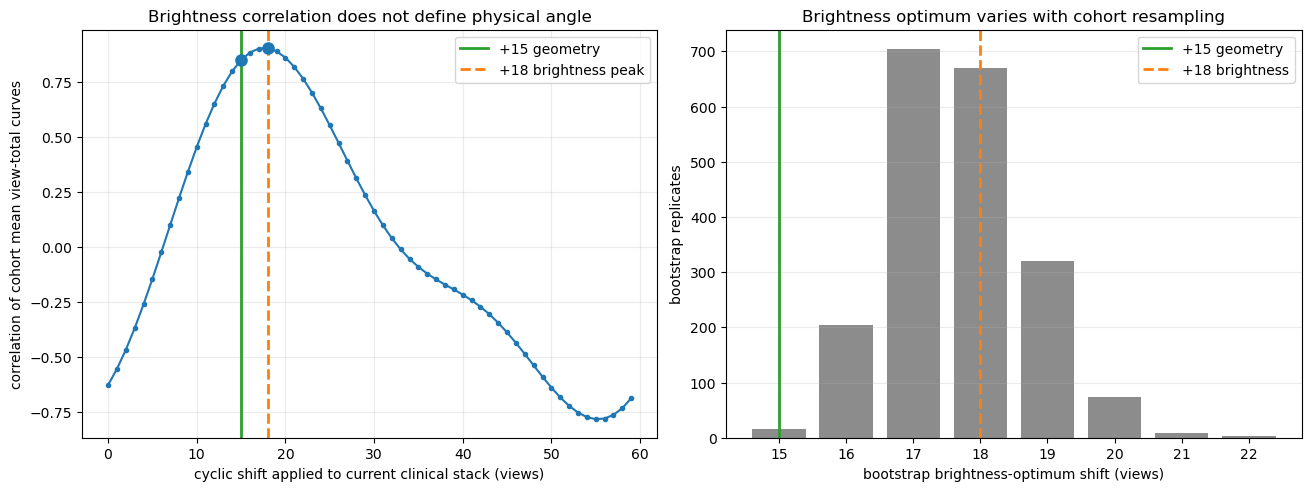

In [5]:
figure, axes = plt.subplots(1, 2, figsize=(13, 4.8), constrained_layout=True)

shifts = np.arange(60)
axes[0].plot(shifts, correlation_by_shift, marker="o", markersize=3)
axes[0].axvline(
    15, linewidth=2, color="tab:green", label="+15 geometry"
)
axes[0].axvline(
    18, linewidth=2, linestyle="--", color="tab:orange",
    label="+18 brightness peak",
)
axes[0].scatter(
    [15, 18],
    [correlation_by_shift[15], correlation_by_shift[18]],
    s=65,
    zorder=4,
)
axes[0].set_xlabel("cyclic shift applied to current clinical stack (views)")
axes[0].set_ylabel("correlation of cohort mean view-total curves")
axes[0].set_title("Brightness correlation does not define physical angle")
axes[0].legend()
axes[0].grid(alpha=0.25)

bootstrap_x = np.array(sorted(bootstrap_counts))
bootstrap_y = np.array([bootstrap_counts[value] for value in bootstrap_x])
axes[1].bar(bootstrap_x, bootstrap_y, color="0.55")
axes[1].axvline(
    15, linewidth=2, color="tab:green", label="+15 geometry"
)
axes[1].axvline(
    18, linewidth=2, linestyle="--", color="tab:orange",
    label="+18 brightness",
)
axes[1].set_xlabel("bootstrap brightness-optimum shift (views)")
axes[1].set_ylabel("bootstrap replicates")
axes[1].set_title("Brightness optimum varies with cohort resampling")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.25)
plt.show()


## 4. Frame-by-frame review of the two candidates

This display uses typical synthetic `case_00020` and clinical `patient_AC`.
The images come from different patients, so appearance is qualitative. The
titles, however, use the actual DICOM source-frame and angle mapping.


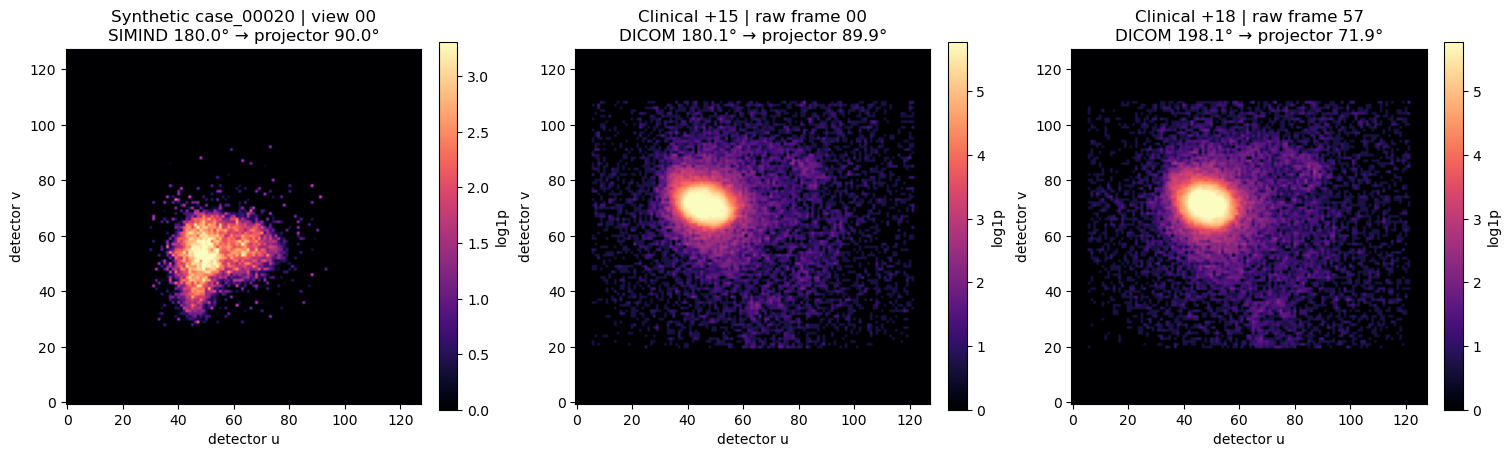

Change `view=0` above to any integer from 0 to 59 for another frame-by-frame comparison.

In [6]:
synthetic_case_id = "case_00020"
clinical_patient_id = "patient_AC"
synthetic_review = synthetic_stacks[synthetic_case_id]
clinical_current = clinical_stacks[clinical_patient_id]
source_indices_current = clinical_source_indices[clinical_patient_id]
clinical_plus15 = np.roll(clinical_current, 15, axis=0)
clinical_plus18 = np.roll(clinical_current, 18, axis=0)
source_indices_plus15 = np.roll(source_indices_current, 15)
source_indices_plus18 = np.roll(source_indices_current, 18)
review_meta = clinical_metadata[clinical_patient_id]


def fixed_vmax(stack, scale):
    values = np.log1p(stack) if scale == "log1p" else stack
    positive = values[values > 0]
    return float(np.percentile(positive, 99.5)) if positive.size else 1.0


def dicom_angle_for_raw_frame(raw_frame):
    sign = -1.0 if review_meta["direction"] == "CW" else 1.0
    return (
        review_meta["start"]
        + sign * int(raw_frame) * review_meta["step"]
    ) % 360.0


def projector_angle_from_dicom(dicom_angle):
    return (270.0 - dicom_angle) % 360.0


def show_candidate_views(view=0, display_scale="log1p"):
    raw15 = int(source_indices_plus15[view])
    raw18 = int(source_indices_plus18[view])
    dicom15 = dicom_angle_for_raw_frame(raw15)
    dicom18 = dicom_angle_for_raw_frame(raw18)
    projector15 = projector_angle_from_dicom(dicom15)
    projector18 = projector_angle_from_dicom(dicom18)
    simind_angle = (180.0 + view * 6.0) % 360.0
    expected_projector = (90.0 + view * 6.0) % 360.0

    panels = [
        (
            synthetic_review[view],
            synthetic_review,
            f"Synthetic {synthetic_case_id} | view {view:02d}\n"
            f"SIMIND {simind_angle:.1f}° → projector {expected_projector:.1f}°",
        ),
        (
            clinical_plus15[view],
            clinical_plus15,
            f"Clinical +15 | raw frame {raw15:02d}\n"
            f"DICOM {dicom15:.1f}° → projector {projector15:.1f}°",
        ),
        (
            clinical_plus18[view],
            clinical_plus18,
            f"Clinical +18 | raw frame {raw18:02d}\n"
            f"DICOM {dicom18:.1f}° → projector {projector18:.1f}°",
        ),
    ]
    figure, axes = plt.subplots(
        1, 3, figsize=(15, 4.8), constrained_layout=True
    )
    for axis, (image, stack, title) in zip(axes, panels):
        shown = np.log1p(image) if display_scale == "log1p" else image
        artist = axis.imshow(
            shown,
            origin="lower",
            cmap="magma",
            vmin=0.0,
            vmax=fixed_vmax(stack, display_scale),
        )
        axis.set_title(title)
        axis.set_xlabel("detector u")
        axis.set_ylabel("detector v")
        figure.colorbar(artist, ax=axis, shrink=0.78, label=display_scale)
    plt.show()


show_candidate_views(view=0, display_scale="log1p")
display(
    Markdown(
        "Change `view=0` above to any integer from 0 to 59 for another "
        "frame-by-frame comparison."
    )
)


## 5. Decision supported by this evidence

- **+15 views has direct geometry support.** Across all 16 DICOM studies it
  maps canonical projector view 0 to 90° with at most 0.19° rounding/header
  error.
- **+18 views has no matching geometry support.** It maps the same view to
  approximately 72°, leaving at least 18.1° error in every study.
- The +18 peak is a cross-patient brightness statistic. Its advantage over +15
  is not stable at the 95% bootstrap level, and individual-patient optima are
  widely dispersed.
- This establishes the preferred calibration candidate but does **not** modify
  clinical preprocessing or the Generator. Any future implementation requires
  a separate reviewed change and regression gate.

**Conclusion: choose +15 as the geometry-backed candidate; reject +18 as a
physical angle calibration.**


## 6. Read-only integrity check


In [7]:
input_snapshot_after = {
    str(path.resolve()): (path.stat().st_size, path.stat().st_mtime_ns)
    for path in tracked_input_paths
}
assert input_snapshot_after == input_snapshot_before
assert marker["manifest_sha256"] == EXPECTED_MANIFEST_SHA256
display(
    {
        "status": "PASS",
        "tracked_inputs_unchanged": len(input_snapshot_after),
        "dataset_manifest_sha256": marker["manifest_sha256"],
        "writes_to_dataset_or_qa": False,
        "gate_authority": "none_informational_read_only",
    }
)


{'status': 'PASS',
 'tracked_inputs_unchanged': 52,
 'dataset_manifest_sha256': 'd44a77f4604bc1df192c6af0674341c704d4e069d1665e1fe159832adfeae722',
 'writes_to_dataset_or_qa': False,
 'gate_authority': 'none_informational_read_only'}